# Week 3 SQL Assignment
## Data Loading and Schema Standardization

### Objective

The objective of this assignment is to analyze Superstore sales data using Subqueries, Common Table Expressions (CTEs), and Window Functions in PostgreSQL.

## Step 1: Schema Standardization

The imported dataset columns were converted into appropriate PostgreSQL datatypes such as DATE, NUMERIC, INTEGER, and BIGINT for proper analysis.

In [ ]:

ALTER TABLE superstore_raw
ALTER COLUMN "Row ID" TYPE BIGINT
USING "Row ID"::BIGINT;


ALTER TABLE superstore_raw
ALTER COLUMN "Order Date" TYPE DATE
USING TO_DATE("Order Date", 'MM/DD/YYYY');

ALTER TABLE superstore_raw
ALTER COLUMN "Ship Date" TYPE DATE
USING TO_DATE("Ship Date", 'MM/DD/YYYY');


ALTER TABLE superstore_raw
ALTER COLUMN "Postal Code" TYPE BIGINT
USING "Postal Code"::BIGINT;

ALTER TABLE superstore_raw
ALTER COLUMN "Sales" TYPE NUMERIC(10,2)
USING "Sales"::NUMERIC;


ALTER TABLE superstore_raw
ALTER COLUMN "Quantity" TYPE INTEGER
USING "Quantity"::INTEGER;


ALTER TABLE superstore_raw
ALTER COLUMN "Discount" TYPE NUMERIC(4,2)
USING "Discount"::NUMERIC;


ALTER TABLE superstore_raw
ALTER COLUMN "Profit" TYPE NUMERIC(10,2)
USING "Profit"::NUMERIC;

## Observation:

The datatype conversion was completed successfully. Date and numeric fields are now properly formatted for performing SQL analysis and business queries.

## Step 2: Creating Customers, Products, and Orders Tables

Separate customers, products, and orders tables were created from the raw Superstore dataset using SELECT DISTINCT statements.

In [ ]:

DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS orders;



CREATE TABLE customers (
    customer_id VARCHAR(50) PRIMARY KEY,
    customer_name TEXT,
    segment TEXT
);


INSERT INTO customers (customer_id, customer_name, segment)

SELECT DISTINCT
    "Customer ID",
    "Customer Name",
    "Segment"
FROM superstore_raw;



CREATE TABLE products (
    product_id VARCHAR(50),
    product_name TEXT,
    category TEXT,
    sub_category TEXT
);

INSERT INTO products (product_id, product_name, category, sub_category)

SELECT DISTINCT
    "Product ID",
    "Product Name",
    "Category",
    "Sub-Category"
FROM superstore_raw;


CREATE TABLE orders (
    order_id VARCHAR(50),
    order_date DATE,
    ship_date DATE,
    customer_id VARCHAR(50),
    sales NUMERIC(10,2),
    quantity INTEGER,
    profit NUMERIC(10,2),
    region TEXT,
    state TEXT
);


INSERT INTO orders (
    order_id,
    order_date,
    ship_date,
    customer_id,
    sales,
    quantity,
    profit,
    region,
    state
)

SELECT DISTINCT
    "Order ID",
    "Order Date",
    "Ship Date",
    "Customer ID",
    "Sales",
    "Quantity",
    "Profit",
    "Region",
    "State"
FROM superstore_raw;

## Observation:

The tables were successfully created and populated using distinct records from the raw dataset. This structure helps organize customer, product, and order information separately for analysis.

## Query 1: Orders with Sales Greater Than Average Sales

In [ ]:
SELECT
    order_id,
    customer_id,
    sales
FROM orders
WHERE sales > (
    SELECT AVG(sales)
    FROM orders
);

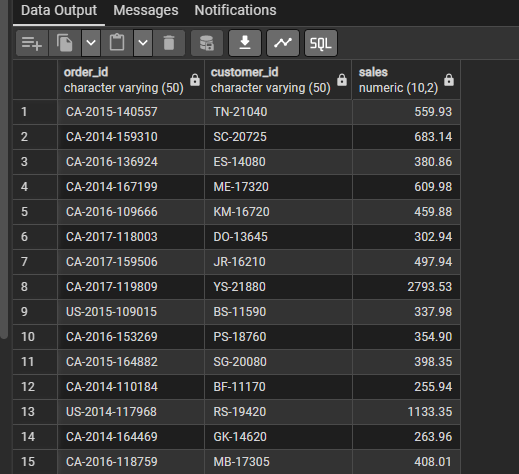

This query uses a subquery to find all orders where the sales value is greater than the average sales across all orders.

Observation:

The query filtered orders having sales higher than the overall average sales value. This helps identify higher-value transactions.

## Query 2: Highest Sales Order for Each Customer

This query finds the highest sales order placed by each customer using a correlated subquery.

In [ ]:

SELECT
    customer_id,
    order_id,
    sales
FROM orders o1
WHERE sales = (
    SELECT MAX(sales)
    FROM orders o2
    WHERE o1.customer_id = o2.customer_id
)
ORDER BY sales DESC;

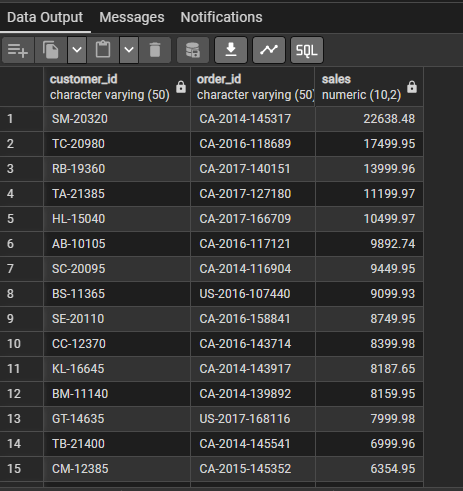

Observation:

The query identified the highest-value order for each customer. Some customers had multiple orders with the same highest sales amount.

## Query 3: Calculate Total Sales for Each Customer Using CTE

This query uses a Common Table Expression (CTE) to calculate the total sales generated by each customer.

In [ ]:

WITH customer_sales AS (

    SELECT
        customer_id,
        SUM(sales) AS total_sales
    FROM orders
    GROUP BY customer_id

)

SELECT *
FROM customer_sales
ORDER BY total_sales DESC;

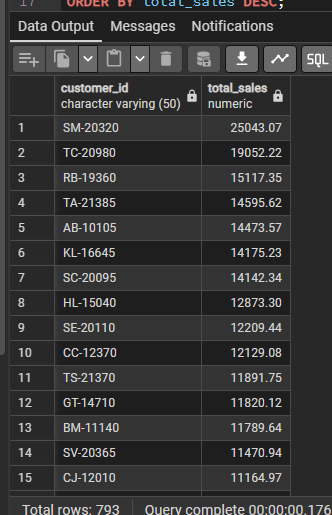

Observation:

The query calculated total sales for each customer successfully. Some customers contributed significantly higher sales compared to others.

## Query 4: Customers with Above Average Total Sales

This query combines a CTE and a subquery to identify customers whose total sales are greater than the average customer sales.

In [ ]:


WITH customer_sales AS (

    SELECT
        customer_id,
        SUM(sales) AS total_sales
    FROM orders
    GROUP BY customer_id

)

SELECT *
FROM customer_sales
WHERE total_sales > (

    SELECT AVG(total_sales)
    FROM customer_sales

)
ORDER BY total_sales DESC;

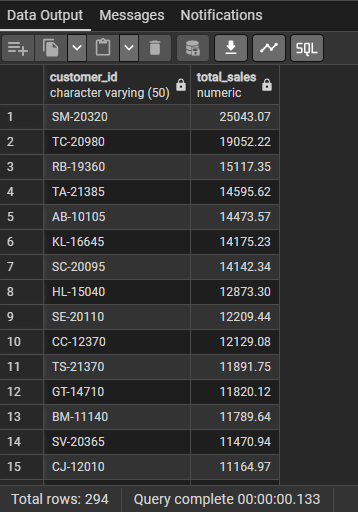

Observation:

The query identified customers whose total sales exceeded the average sales value among all customers.

## Query 5: Rank Customers Based on Total Sales

This query uses the RANK() window function to rank customers according to their total sales.

In [ ]:


WITH customer_sales AS (

    SELECT
        customer_id,
        SUM(sales) AS total_sales
    FROM orders
    GROUP BY customer_id

)

SELECT
    customer_id,
    total_sales,

    RANK() OVER (
        ORDER BY total_sales DESC
    ) AS sales_rank

FROM customer_sales;

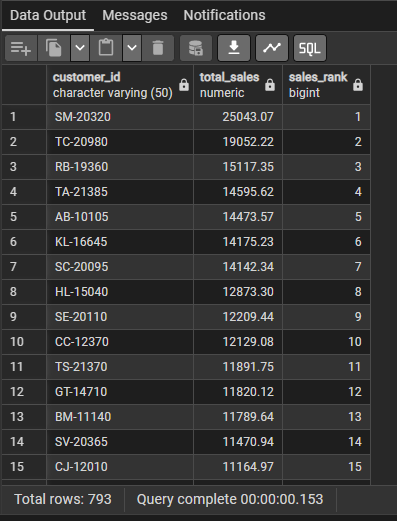

Observation:

The ranking function assigned ranks to customers based on total sales. Customers with higher sales received better ranks.

## Query 6: Assign Row Numbers to Orders Within Each Customer

This query uses ROW_NUMBER() and PARTITION BY to assign row numbers to orders separately for each customer.

In [ ]:


SELECT
    customer_id,
    order_id,
    sales,

    ROW_NUMBER() OVER (

        PARTITION BY customer_id
        ORDER BY sales DESC

    ) AS row_number

FROM orders;

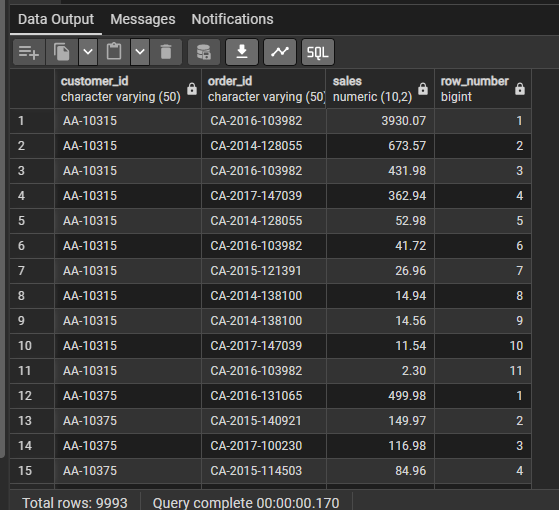

Observation:

The query assigned separate row numbers for orders within each customer group based on sales values.

## Query 7: Top 3 Customers Based on Total Sales

This query identifies the top 3 customers based on total sales using CTEs and the RANK() window function.

In [ ]:

WITH customer_sales AS (

    SELECT
        customer_id,
        SUM(sales) AS total_sales
    FROM orders
    GROUP BY customer_id

),

customer_rank AS (

    SELECT
        customer_id,
        total_sales,

        RANK() OVER (
            ORDER BY total_sales DESC
        ) AS sales_rank

    FROM customer_sales

)

SELECT *
FROM customer_rank
WHERE sales_rank <= 3;

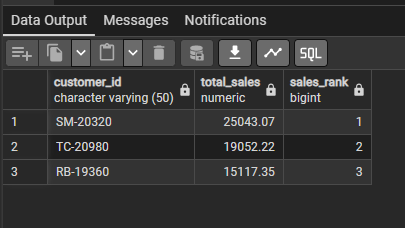

Observation:

The query successfully identified the highest-performing customers based on total sales values.

## Final Combined Query: Customer Sales Ranking

This query combines JOIN, CTE, and Window Functions to display customer names, total sales, and sales ranking.

In [ ]:

WITH customer_sales AS (

    SELECT
        customer_id,
        SUM(sales) AS total_sales
    FROM orders
    GROUP BY customer_id

),

customer_rank AS (

    SELECT
        customer_id,
        total_sales,

        RANK() OVER (
            ORDER BY total_sales DESC
        ) AS sales_rank

    FROM customer_sales

)

SELECT
    c.customer_name,
    cr.total_sales,
    cr.sales_rank

FROM customer_rank cr

JOIN customers c
ON cr.customer_id = c.customer_id

ORDER BY cr.sales_rank;

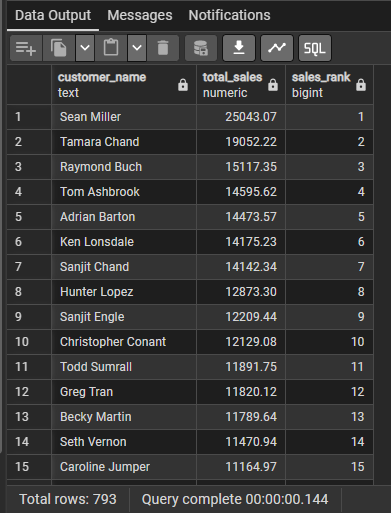

Observation:

The final query combined multiple SQL concepts to generate a ranked customer sales report. Customers were ranked according to their total sales values.